<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB2/EXPERIENCIA_1/RA1_Lab_N%C2%B02_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiencia 1 — Sistema supervisado de detección de fraude bancario

**Dataset:** `creditcard.csv`

**Grupo:** N° 8 ·

**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustín · **Fecha:** 04/2026



## 0. Setup y reproducibilidad

In [ ]:
# Instalación de paquetes no estándar en Colab
import sys, subprocess
def _pip(pkgs):
    try:
        subprocess.check_call([sys.executable,"-m","pip","install","-q",*pkgs],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception:
        try:
            subprocess.check_call([sys.executable,"-m","pip","install","-q",
                                   "--break-system-packages",*pkgs],
                                  stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        except Exception:
            pass

try: import imblearn
except ImportError: _pip(["imbalanced-learn"])
try: import gdown
except ImportError: _pip(["gdown"])


In [ ]:
import os, random, warnings, time, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
try: tf.keras.utils.set_random_seed(SEED)
except Exception: pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(context="notebook", style="whitegrid", palette="deep")

# Carpeta para guardar las figuras que se incluirán en el informe.
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name, fig=None, dpi=140):
    """Guarda la figura actual como PNG dentro de FIG_DIR."""
    fig = fig or plt.gcf()
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    return path

print("TensorFlow:", tf.__version__)
print("GPU:", "sí" if tf.config.list_physical_devices('GPU') else "no")


I0000 00:00:1778791823.489295     537 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778791823.492665     537 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778791845.739898     537 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1778791857.326574     537 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778791857.329727     537 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPU: no


E0000 00:00:1778791858.597838     537 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Carga del dataset


In [ ]:
import gdown
FILE_ID = "1Zy1fV1U5nXj8XXhcqEI4YjEmlzbodk0n"
ZIP_PATH = "creditcard.zip"
CSV_PATH = "creditcard.csv"

if not os.path.exists(CSV_PATH):
    if not os.path.exists(ZIP_PATH):
        gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")

df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}  |  Fraudes: {int(df['Class'].sum())}  |  Tasa: {df['Class'].mean():.4%}")
df.head()


Shape: (284807, 31)  |  Fraudes: 492  |  Tasa: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Integridad y deduplicación
print("Nulos totales:", int(df.isna().sum().sum()))
print("Duplicados   :", int(df.duplicated().sum()))
df = df.drop_duplicates().reset_index(drop=True)
print(f"Tras deduplicar — Shape: {df.shape}  |  Tasa fraude: {df['Class'].mean():.4%}")


Nulos totales: 0


Duplicados   : 1081


Tras deduplicar — Shape: (283726, 31)  |  Tasa fraude: 0.1667%


## 2. EDA

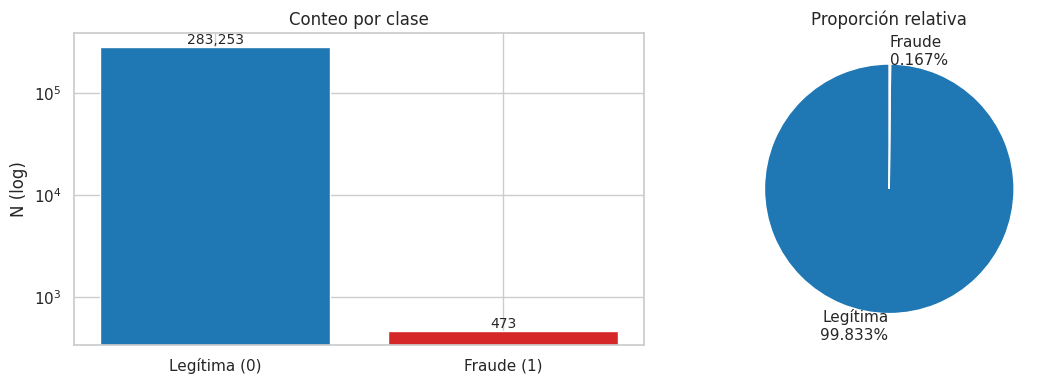

Por cada fraude hay ~599 transacciones legítimas.


In [ ]:
# fig01 — Desbalance de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["Class"].value_counts().sort_index()
axes[0].bar(["Legítima (0)", "Fraude (1)"], counts.values, color=["#1f77b4", "#d62728"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)
axes[0].set_yscale("log"); axes[0].set_ylabel("N (log)")
axes[0].set_title("Conteo por clase")

pct = counts / counts.sum() * 100
axes[1].pie(pct.values, labels=[f"Legítima\n{pct.iloc[0]:.3f}%", f"Fraude\n{pct.iloc[1]:.3f}%"],
            colors=["#1f77b4","#d62728"], startangle=90, wedgeprops={"edgecolor":"white"})
axes[1].set_title("Proporción relativa")
plt.tight_layout()
savefig("fig01_desbalance_clases.png")
plt.show()

ratio = counts.iloc[0] / counts.iloc[1]
print(f"Por cada fraude hay ~{ratio:,.0f} transacciones legítimas.")


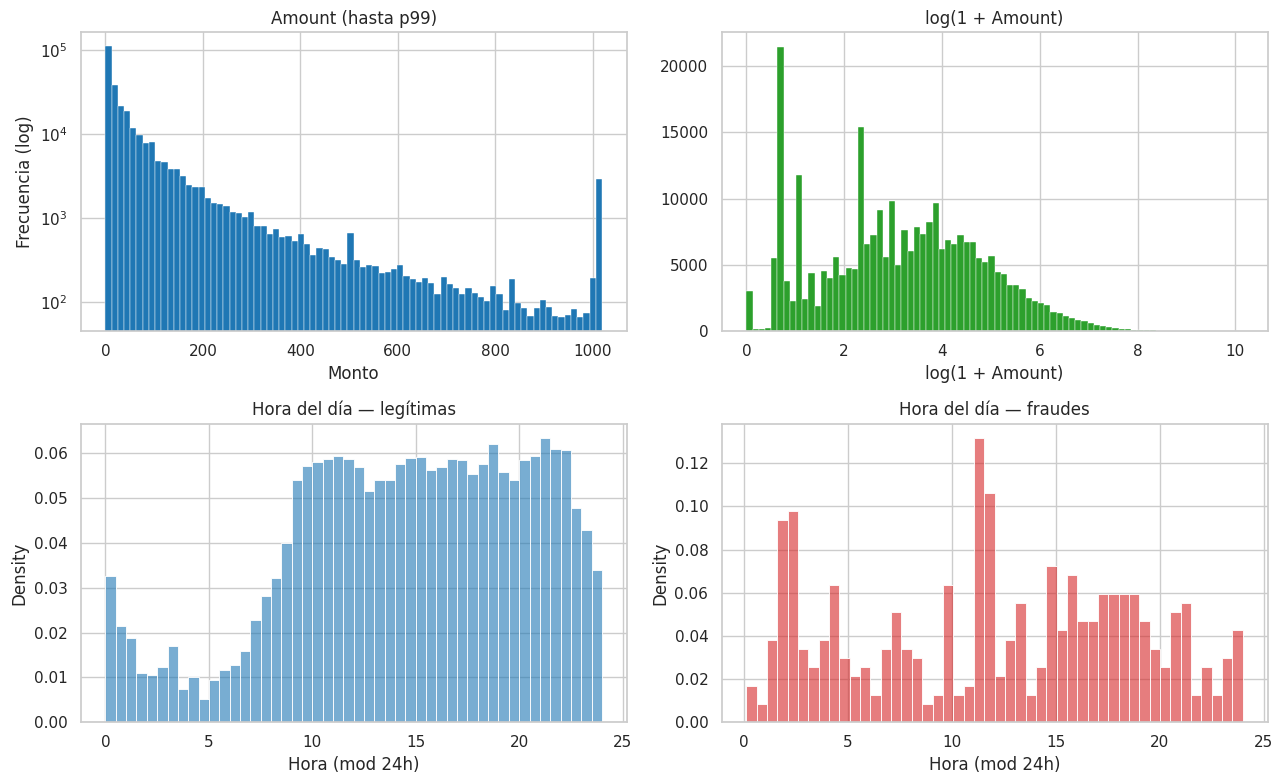

In [ ]:
# fig02 — Distribución de Amount y Time (con ciclo de 24 h)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].hist(df["Amount"].clip(upper=df["Amount"].quantile(0.99)),
               bins=80, color="#1f77b4", edgecolor="white", linewidth=0.3)
axes[0,0].set_title("Amount (hasta p99)"); axes[0,0].set_yscale("log")
axes[0,0].set_xlabel("Monto"); axes[0,0].set_ylabel("Frecuencia (log)")

axes[0,1].hist(np.log1p(df["Amount"]), bins=80, color="#2ca02c", edgecolor="white", linewidth=0.3)
axes[0,1].set_title("log(1 + Amount)"); axes[0,1].set_xlabel("log(1 + Amount)")

hour = (df["Time"] / 3600.0) % 24
sns.histplot(x=hour[df["Class"]==0], bins=48, ax=axes[1,0], color="#1f77b4", stat="density", alpha=0.6)
axes[1,0].set_title("Hora del día — legítimas"); axes[1,0].set_xlabel("Hora (mod 24h)")
sns.histplot(x=hour[df["Class"]==1], bins=48, ax=axes[1,1], color="#d62728", stat="density", alpha=0.6)
axes[1,1].set_title("Hora del día — fraudes"); axes[1,1].set_xlabel("Hora (mod 24h)")

plt.tight_layout()
savefig("fig02_distribucion_amount_time.png")
plt.show()


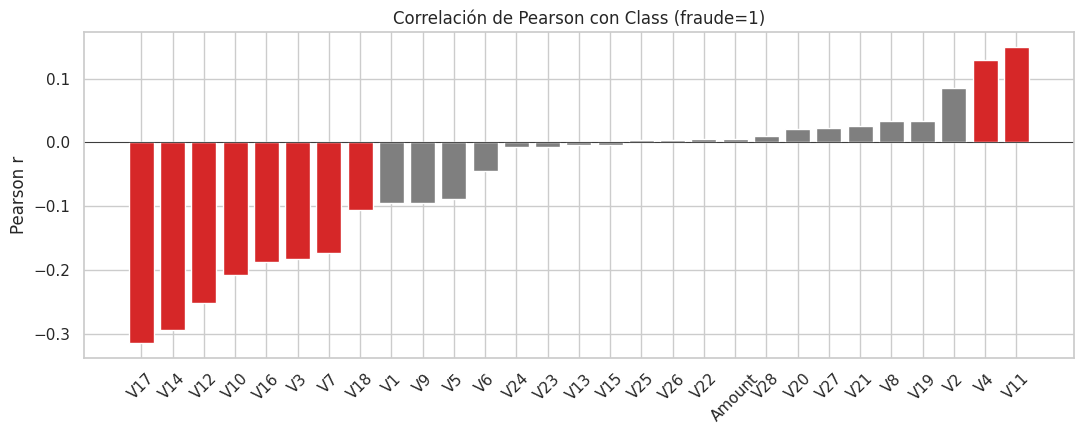

Top 6 por |corr|: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


In [ ]:
# fig03 — Correlación de V1..V28 y Amount con Class
v_cols = [f"V{i}" for i in range(1, 29)]
corrs = df[v_cols + ["Amount", "Class"]].corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["#d62728" if abs(c) > 0.1 else "#7f7f7f" for c in corrs.values]
ax.bar(corrs.index, corrs.values, color=colors)
ax.set_title("Correlación de Pearson con Class (fraude=1)")
ax.set_ylabel("Pearson r")
ax.axhline(0, color='black', lw=0.5)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
savefig("fig03_correlacion_features_class.png")
plt.show()

top_features = corrs.abs().sort_values(ascending=False).head(6).index.tolist()
print("Top 6 por |corr|:", top_features)


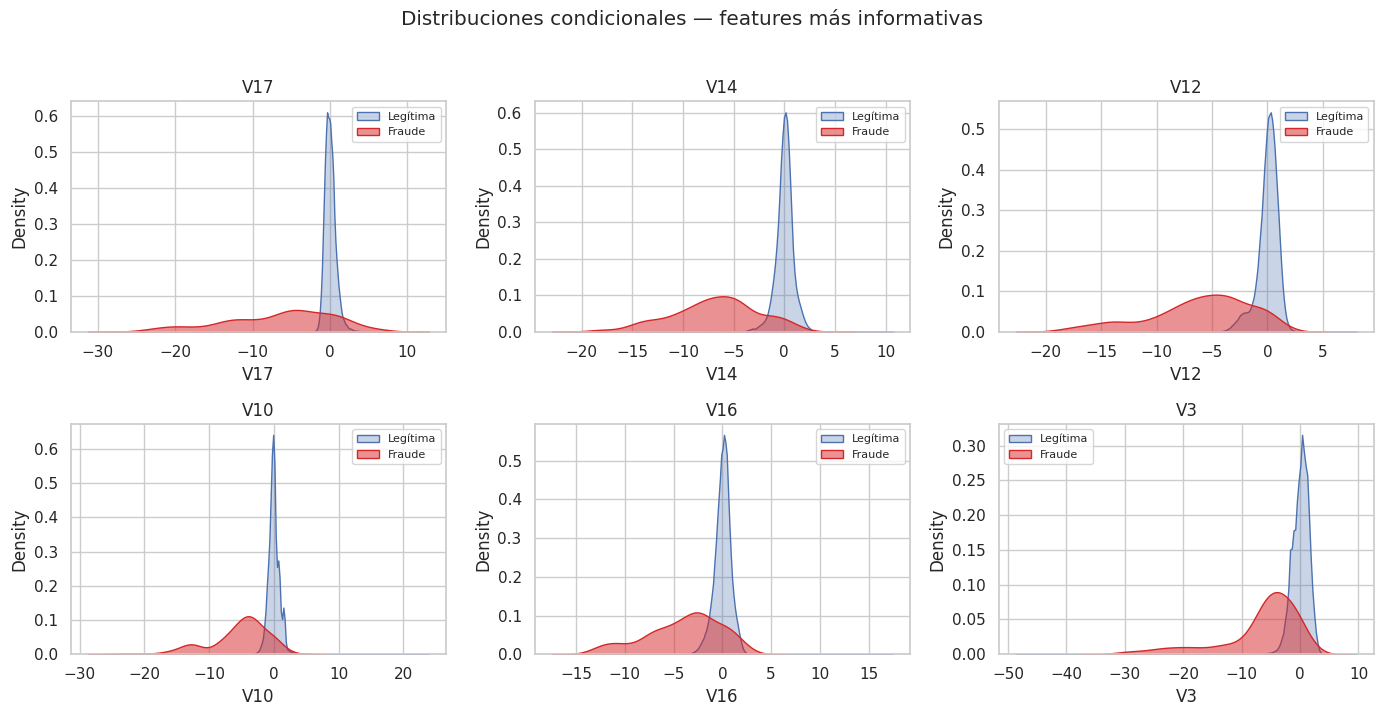

In [ ]:
# fig04 — Distribución por clase en las 6 features más informativas
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, top_features):
    sns.kdeplot(data=df[df["Class"]==0], x=col, ax=ax, fill=True, alpha=0.3, label="Legítima")
    sns.kdeplot(data=df[df["Class"]==1], x=col, ax=ax, fill=True, alpha=0.5,
                label="Fraude", color="#d62728")
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle("Distribuciones condicionales — features más informativas", y=1.02)
plt.tight_layout()
savefig("fig04_distribuciones_top_features.png")
plt.show()


## 3. División train / val / test estratificada

70 / 15 / 15. Se hace antes de cualquier transformación supervisada y antes de cualquier resampling para evitar leakage.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"]).copy()
y = df["Class"].astype(int).copy()

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=SEED, stratify=y_trainval)

print(pd.DataFrame({
    "N": [len(y_train), len(y_val), len(y_test)],
    "Fraudes": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "Tasa (%)": [100*y_train.mean(), 100*y_val.mean(), 100*y_test.mean()],
}, index=["Train","Val","Test"]).round(4))


            N  Fraudes  Tasa (%)
Train  198608      331    0.1667
Val     42559       71    0.1668
Test    42559       71    0.1668


## 4. Pipeline de preprocesamiento

`RobustScaler` para `Amount` (cola larga), `StandardScaler` para `Time`, passthrough para `V1..V28` (ya escaladas por PCA).

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("amount", RobustScaler(),  ["Amount"]),
    ("time",   StandardScaler(), ["Time"]),
    ("v",      "passthrough",   v_cols),
])
preprocessor.fit(X_train)

X_train_p = preprocessor.transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)
print("Shape train preprocesado:", X_train_p.shape)


Shape train preprocesado: (198608, 30)


## 5. Función de evaluación común

In [ ]:
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             roc_auc_score, confusion_matrix,
                             fbeta_score, f1_score, precision_score, recall_score)

def evaluate(y_true, y_score, threshold=0.5, label=""):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": label, "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "f2":        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "pr_auc":    average_precision_score(y_true, y_score),
        "roc_auc":   roc_auc_score(y_true, y_score),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def print_eval(res):
    print(f"--- {res['model']}  (umbral={res['threshold']:.4f}) ---")
    print(f"  Precision={res['precision']:.4f}  Recall={res['recall']:.4f}  "
          f"F1={res['f1']:.4f}  F2={res['f2']:.4f}")
    print(f"  PR-AUC={res['pr_auc']:.4f}   ROC-AUC={res['roc_auc']:.4f}")
    print(f"  TN={res['tn']:,}  FP={res['fp']:,}  FN={res['fn']:,}  TP={res['tp']:,}")


## 6. Baseline no supervisado: Isolation Forest

Se reentrena IF sobre el mismo `train` de esta experiencia (199k filas, sin etiquetas) y se evalúa sobre el mismo `test` (~42k) que verá el supervisado. Esto aísla el efecto del paradigma: misma escala de datos, mismo split, misma métrica.

In [ ]:
from sklearn.ensemble import IsolationForest

iforest = IsolationForest(
    n_estimators=200,
    contamination=float(y_train.mean()),  # tasa real del train (~0.0017)
    max_samples="auto",
    random_state=SEED, n_jobs=-1,
)
iforest.fit(X_train_p)

# Score continuo (mayor = más anómalo) para evaluación por curva
val_score_if  = -iforest.decision_function(X_val_p)
test_score_if = -iforest.decision_function(X_test_p)

# Umbral derivado del contamination (top ~0.17% como anomalía)
thr_if = np.quantile(val_score_if, 1 - float(y_train.mean()))
res_if_val  = evaluate(y_val,  val_score_if,  threshold=thr_if, label="IF [VAL]")
res_if_test = evaluate(y_test, test_score_if, threshold=thr_if, label="IF [TEST]")
print_eval(res_if_val); print()
print_eval(res_if_test)


--- IF [VAL]  (umbral=0.0130) ---
  Precision=0.2817  Recall=0.2817  F1=0.2817  F2=0.2817
  PR-AUC=0.1450   ROC-AUC=0.9522
  TN=42,437  FP=51  FN=51  TP=20

--- IF [TEST]  (umbral=0.0130) ---
  Precision=0.1852  Recall=0.1408  F1=0.1600  F2=0.1479
  PR-AUC=0.1094   ROC-AUC=0.9251
  TN=42,444  FP=44  FN=61  TP=10


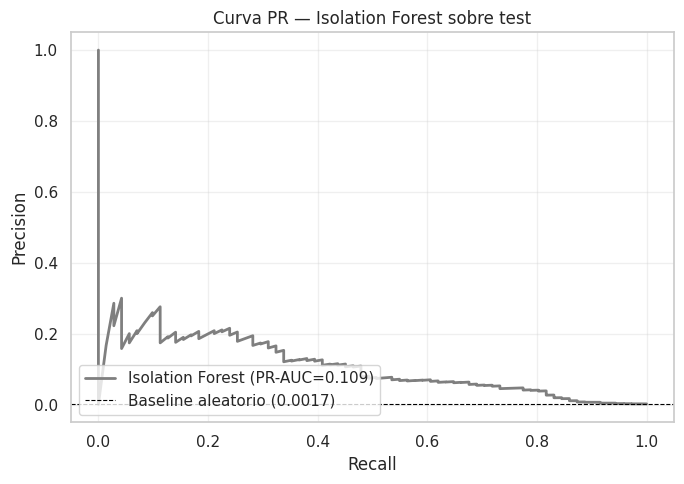

In [ ]:
# fig05 — Curva PR del Isolation Forest sobre test (línea base)
p, r, _ = precision_recall_curve(y_test, test_score_if)
ap = average_precision_score(y_test, test_score_if)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(r, p, color="#7f7f7f", lw=2, label=f"Isolation Forest (PR-AUC={ap:.3f})")
ax.axhline(y_test.mean(), ls="--", color="black", lw=0.8,
           label=f"Baseline aleatorio ({y_test.mean():.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Curva PR — Isolation Forest sobre test")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout()
savefig("fig05_isolation_forest_baseline.png")
plt.show()


## 7. Numero de muestras óptimo

Regresión logística con `class_weight='balanced'` sobre dataset completo vs submuestra estratificada (200 negativos por positivo). Mismo set de validación.

In [ ]:
from sklearn.linear_model import LogisticRegression

def stratified_subsample(X, y, neg_per_pos=200, random_state=SEED):
    rng = np.random.RandomState(random_state)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    n_neg = min(len(neg_idx), neg_per_pos * len(pos_idx))
    neg_sample = rng.choice(neg_idx, size=n_neg, replace=False)
    keep = np.concatenate([pos_idx, neg_sample]); rng.shuffle(keep)
    return X[keep], (y.iloc[keep] if hasattr(y, "iloc") else y[keep])

X_tr_sub, y_tr_sub = stratified_subsample(X_train_p, y_train, neg_per_pos=200)

t0 = time.time()
lr_full = LogisticRegression(max_iter=2000, class_weight="balanced",
                             solver="liblinear", random_state=SEED).fit(X_train_p, y_train)
t_full = time.time() - t0

t0 = time.time()
lr_sub = LogisticRegression(max_iter=2000, class_weight="balanced",
                            solver="liblinear", random_state=SEED).fit(X_tr_sub, y_tr_sub)
t_sub = time.time() - t0

score_full = lr_full.predict_proba(X_val_p)[:, 1]
score_sub  = lr_sub.predict_proba(X_val_p)[:, 1]

res_full = evaluate(y_val, score_full, 0.5, f"LR completo (N={X_train_p.shape[0]:,}, {t_full:.1f}s)")
res_sub  = evaluate(y_val, score_sub,  0.5, f"LR submuestreado (N={X_tr_sub.shape[0]:,}, {t_sub:.1f}s)")
print_eval(res_full); print()
print_eval(res_sub)


--- LR completo (N=198,608, 4.0s)  (umbral=0.5000) ---
  Precision=0.0612  Recall=0.9155  F1=0.1147  F2=0.2415
  PR-AUC=0.7217   ROC-AUC=0.9767
  TN=41,491  FP=997  FN=6  TP=65

--- LR submuestreado (N=66,531, 0.8s)  (umbral=0.5000) ---
  Precision=0.0586  Recall=0.9155  F1=0.1101  F2=0.2331
  PR-AUC=0.7205   ROC-AUC=0.9768
  TN=41,443  FP=1,045  FN=6  TP=65


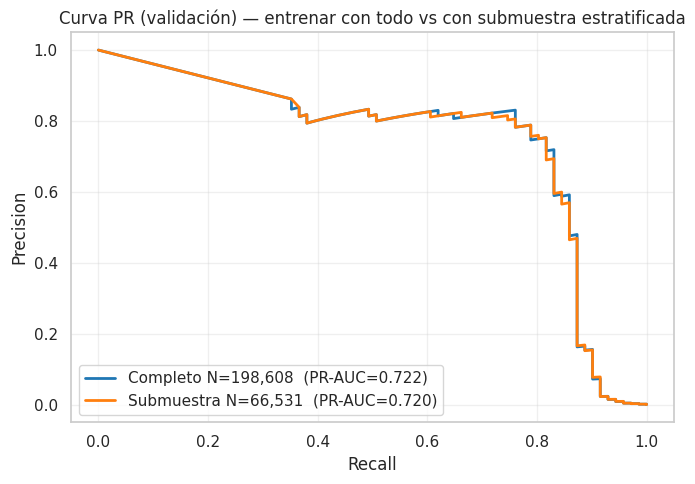

In [ ]:
# fig06 — Curva PR completo vs submuestreado
fig, ax = plt.subplots(figsize=(7, 5))
for score, name, color in [(score_full, f"Completo N={X_train_p.shape[0]:,}", "#1f77b4"),
                           (score_sub,  f"Submuestra N={X_tr_sub.shape[0]:,}", "#ff7f0e")]:
    p, r, _ = precision_recall_curve(y_val, score)
    ap = average_precision_score(y_val, score)
    ax.plot(r, p, label=f"{name}  (PR-AUC={ap:.3f})", color=color, lw=2)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Curva PR (validación) — entrenar con todo vs con submuestra estratificada")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout()
savefig("fig06_muestreo_estratificado.png")
plt.show()


## 8. Comparación de estrategias de desbalance

Misma MLP base con tres estrategias: `class_weight`, SMOTE en pipeline (solo train) y `RandomUnderSampler`. Métrica de selección: PR-AUC sobre validación.

In [ ]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def build_mlp(input_dim, hidden=(64, 32), dropout=0.3, lr=1e-3, name="mlp"):
    inp = Input(shape=(input_dim,), name="inp")
    x = inp
    for i, units in enumerate(hidden):
        x = layers.Dense(units, kernel_initializer="he_normal", name=f"dense_{i}")(x)
        x = layers.BatchNormalization(name=f"bn_{i}")(x)
        x = layers.Activation("relu", name=f"relu_{i}")(x)
        x = layers.Dropout(dropout, name=f"drop_{i}")(x)
    out = layers.Dense(1, activation="sigmoid", name="out")(x)
    m = Model(inp, out, name=name)
    m.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(name="auc"),
                       tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
                       tf.keras.metrics.Precision(name="prec"),
                       tf.keras.metrics.Recall(name="rec")])
    return m

def make_callbacks(patience=5):
    return [EarlyStopping(monitor="val_pr_auc", mode="max", patience=patience,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor="val_pr_auc", mode="max",
                              factor=0.5, patience=3, verbose=0)]

INPUT_DIM = X_train_p.shape[1]
EPOCHS, BATCH = 30, 2048


In [ ]:
# Estrategia 1 — class_weight
from sklearn.utils.class_weight import compute_class_weight
cw_arr = compute_class_weight("balanced", classes=np.array([0,1]), y=y_train.values)
class_weight_dict = {0: float(cw_arr[0]), 1: float(cw_arr[1])}

tf.keras.utils.set_random_seed(SEED)
mlp_cw = build_mlp(INPUT_DIM, name="mlp_cw")
hist_cw = mlp_cw.fit(X_train_p, y_train.values,
                    validation_data=(X_val_p, y_val.values),
                    epochs=EPOCHS, batch_size=BATCH,
                    class_weight=class_weight_dict,
                    callbacks=make_callbacks(), verbose=0)
score_cw = mlp_cw.predict(X_val_p, verbose=0).ravel()
res_cw = evaluate(y_val, score_cw, 0.5, "MLP + class_weight [VAL]")
print_eval(res_cw)


--- MLP + class_weight [VAL]  (umbral=0.5000) ---
  Precision=0.0354  Recall=0.8873  F1=0.0681  F2=0.1526
  PR-AUC=0.6677   ROC-AUC=0.9617
  TN=40,771  FP=1,717  FN=8  TP=63


In [ ]:
# Estrategia 2 — SMOTE (solo sobre train)
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.1, random_state=SEED, k_neighbors=5)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_p, y_train)
print(f"Tras SMOTE: N={len(y_tr_sm):,}  fraudes={int(y_tr_sm.sum())}")

tf.keras.utils.set_random_seed(SEED)
mlp_sm = build_mlp(INPUT_DIM, name="mlp_smote")
hist_sm = mlp_sm.fit(X_tr_sm, y_tr_sm,
                    validation_data=(X_val_p, y_val.values),
                    epochs=EPOCHS, batch_size=BATCH,
                    callbacks=make_callbacks(), verbose=0)
score_sm = mlp_sm.predict(X_val_p, verbose=0).ravel()
res_sm = evaluate(y_val, score_sm, 0.5, "MLP + SMOTE [VAL]")
print_eval(res_sm)


Tras SMOTE: N=218,104  fraudes=19827


--- MLP + SMOTE [VAL]  (umbral=0.5000) ---
  Precision=0.5126  Recall=0.8592  F1=0.6421  F2=0.7568
  PR-AUC=0.7515   ROC-AUC=0.9762
  TN=42,430  FP=58  FN=10  TP=61


In [ ]:
# Estrategia 3 — Undersampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=SEED)
X_tr_us, y_tr_us = rus.fit_resample(X_train_p, y_train)
print(f"Tras RUS: N={len(y_tr_us):,}  fraudes={int(y_tr_us.sum())}")

tf.keras.utils.set_random_seed(SEED)
mlp_us = build_mlp(INPUT_DIM, name="mlp_us")
hist_us = mlp_us.fit(X_tr_us, y_tr_us,
                    validation_data=(X_val_p, y_val.values),
                    epochs=EPOCHS, batch_size=BATCH,
                    callbacks=make_callbacks(), verbose=0)
score_us = mlp_us.predict(X_val_p, verbose=0).ravel()
res_us = evaluate(y_val, score_us, 0.5, "MLP + Undersampling [VAL]")
print_eval(res_us)


Tras RUS: N=3,641  fraudes=331


--- MLP + Undersampling [VAL]  (umbral=0.5000) ---
  Precision=0.0151  Recall=0.8592  F1=0.0296  F2=0.0704
  PR-AUC=0.6954   ROC-AUC=0.9269
  TN=38,502  FP=3,986  FN=10  TP=61


                    model  precision  recall     f1     f2  pr_auc  roc_auc    tn   fp  fn  tp
 MLP + class_weight [VAL]     0.0354  0.8873 0.0681 0.1526  0.6677   0.9617 40771 1717   8  63
        MLP + SMOTE [VAL]     0.5126  0.8592 0.6421 0.7568  0.7515   0.9762 42430   58  10  61
MLP + Undersampling [VAL]     0.0151  0.8592 0.0296 0.0704  0.6954   0.9269 38502 3986  10  61


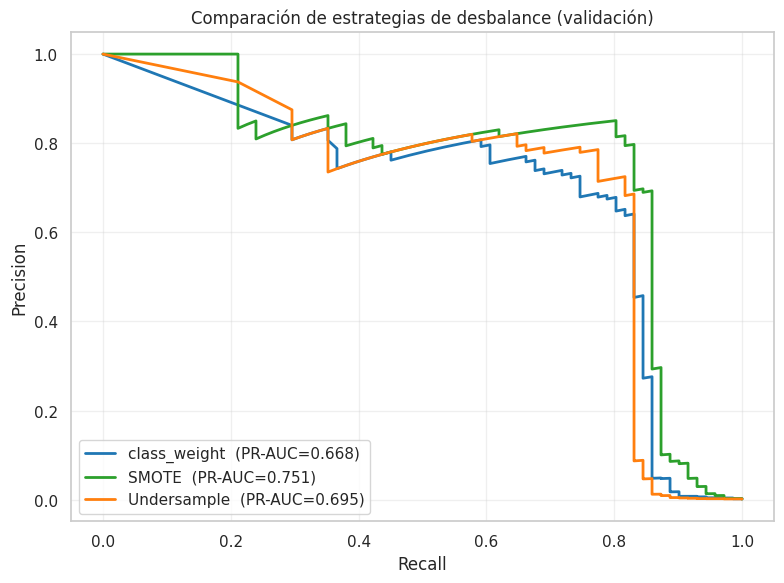


Mejor estrategia por PR-AUC: smote  (PR-AUC=0.7515)


In [ ]:
# fig07 — Comparación de estrategias en validación
comparison = pd.DataFrame([res_cw, res_sm, res_us])[
    ["model","precision","recall","f1","f2","pr_auc","roc_auc","tn","fp","fn","tp"]]
print(comparison.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
for score, name, color in [(score_cw, "class_weight", "#1f77b4"),
                           (score_sm, "SMOTE",        "#2ca02c"),
                           (score_us, "Undersample",  "#ff7f0e")]:
    p, r, _ = precision_recall_curve(y_val, score)
    ap = average_precision_score(y_val, score)
    ax.plot(r, p, label=f"{name}  (PR-AUC={ap:.3f})", color=color, lw=2)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Comparación de estrategias de desbalance (validación)")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout()
savefig("fig07_comparacion_estrategias_desbalance.png")
plt.show()

# Selección automática por PR-AUC
estrategias = {"class_weight": res_cw, "smote": res_sm, "undersample": res_us}
MEJOR = max(estrategias, key=lambda k: estrategias[k]["pr_auc"])
print(f"\nMejor estrategia por PR-AUC: {MEJOR}  (PR-AUC={estrategias[MEJOR]['pr_auc']:.4f})")


## 9. MLP final con la mejor estrategia

In [ ]:
tf.keras.utils.set_random_seed(SEED)
mlp_final = build_mlp(INPUT_DIM, hidden=(64,32), dropout=0.3, lr=1e-3, name="mlp_final")
mlp_final.summary()

fit_kw = dict(validation_data=(X_val_p, y_val.values),
              epochs=50, batch_size=BATCH,
              callbacks=make_callbacks(patience=8), verbose=0)

if MEJOR == "class_weight":
    hist_final = mlp_final.fit(X_train_p, y_train.values, class_weight=class_weight_dict, **fit_kw)
elif MEJOR == "smote":
    hist_final = mlp_final.fit(X_tr_sm, y_tr_sm, **fit_kw)
else:
    hist_final = mlp_final.fit(X_tr_us, y_tr_us, **fit_kw)

print(f"Estrategia usada    : {MEJOR}")
print(f"Épocas efectivas    : {len(hist_final.history['loss'])}")
print(f"Parámetros del modelo: {mlp_final.count_params():,}")


Model: "mlp_final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inp (InputLayer)                │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_0 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

Estrategia usada    : smote
Épocas efectivas    : 33
Parámetros del modelo: 4,481


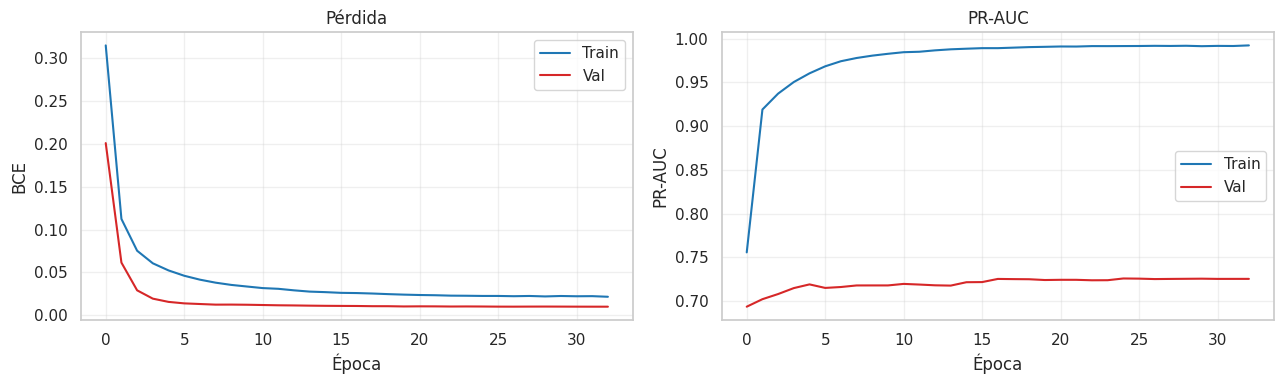

In [ ]:
# fig08 — Curvas de aprendizaje del modelo final
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_final.history["loss"], label="Train", color="#1f77b4")
axes[0].plot(hist_final.history["val_loss"], label="Val", color="#d62728")
axes[0].set_title("Pérdida"); axes[0].set_xlabel("Época"); axes[0].set_ylabel("BCE")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_final.history["pr_auc"], label="Train", color="#1f77b4")
axes[1].plot(hist_final.history["val_pr_auc"], label="Val", color="#d62728")
axes[1].set_title("PR-AUC"); axes[1].set_xlabel("Época"); axes[1].set_ylabel("PR-AUC")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
savefig("fig08_curvas_aprendizaje_mlp.png")
plt.show()


## 10. Análisis de umbral sobre validación

In [ ]:
score_val = mlp_final.predict(X_val_p, verbose=0).ravel()
prec_v, rec_v, thr_v = precision_recall_curve(y_val, score_val)
ap_v = average_precision_score(y_val, score_val)

eps = 1e-12
f1_grid = 2*prec_v*rec_v / (prec_v+rec_v+eps)
beta = 2.0
f2_grid = (1+beta**2)*prec_v*rec_v / (beta**2*prec_v + rec_v + eps)

idx_f1 = int(np.argmax(f1_grid[:-1]))
idx_f2 = int(np.argmax(f2_grid[:-1]))
thr_f1 = float(thr_v[idx_f1])
thr_f2 = float(thr_v[idx_f2])

print(f"PR-AUC validación: {ap_v:.4f}")
print(f"Umbral Max F1: {thr_f1:.4f}  -> P={prec_v[idx_f1]:.3f} R={rec_v[idx_f1]:.3f} F1={f1_grid[idx_f1]:.3f}")
print(f"Umbral Max F2: {thr_f2:.4f}  -> P={prec_v[idx_f2]:.3f} R={rec_v[idx_f2]:.3f} F2={f2_grid[idx_f2]:.3f}")


PR-AUC validación: 0.7543
Umbral Max F1: 0.9744  -> P=0.855 R=0.831 F1=0.843
Umbral Max F2: 0.9744  -> P=0.855 R=0.831 F2=0.836


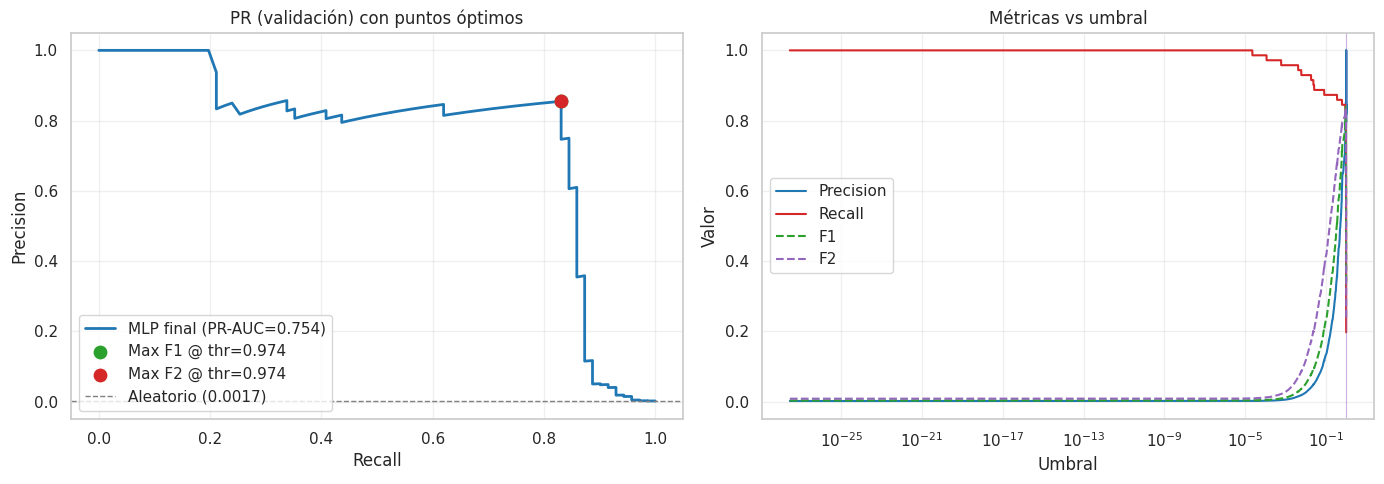

--- MLP val thr=0.5  (umbral=0.5000) ---
  Precision=0.4959  Recall=0.8592  F1=0.6289  F2=0.7494
  PR-AUC=0.7543   ROC-AUC=0.9685
  TN=42,426  FP=62  FN=10  TP=61

--- MLP val thr=0.9744 (F1)  (umbral=0.9744) ---
  Precision=0.8551  Recall=0.8310  F1=0.8429  F2=0.8357
  PR-AUC=0.7543   ROC-AUC=0.9685
  TN=42,478  FP=10  FN=12  TP=59

--- MLP val thr=0.9744 (F2)  (umbral=0.9744) ---
  Precision=0.8551  Recall=0.8310  F1=0.8429  F2=0.8357
  PR-AUC=0.7543   ROC-AUC=0.9685
  TN=42,478  FP=10  FN=12  TP=59



In [ ]:
# fig09 — Curva PR de validación con puntos óptimos y métricas vs umbral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_v, prec_v, color="#1f77b4", lw=2, label=f"MLP final (PR-AUC={ap_v:.3f})")
axes[0].scatter(rec_v[idx_f1], prec_v[idx_f1], color="#2ca02c", s=80, zorder=5,
                label=f"Max F1 @ thr={thr_f1:.3f}")
axes[0].scatter(rec_v[idx_f2], prec_v[idx_f2], color="#d62728", s=80, zorder=5,
                label=f"Max F2 @ thr={thr_f2:.3f}")
axes[0].axhline(y_val.mean(), ls="--", color="gray", lw=1, label=f"Aleatorio ({y_val.mean():.4f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("PR (validación) con puntos óptimos")
axes[0].legend(loc="lower left"); axes[0].grid(alpha=0.3)

axes[1].plot(thr_v, prec_v[:-1], label="Precision", color="#1f77b4")
axes[1].plot(thr_v, rec_v[:-1],  label="Recall",    color="#d62728")
axes[1].plot(thr_v, f1_grid[:-1], label="F1",       color="#2ca02c", ls="--")
axes[1].plot(thr_v, f2_grid[:-1], label="F2",       color="#9467bd", ls="--")
axes[1].axvline(thr_f2, color="#9467bd", lw=0.8, alpha=0.5)
axes[1].set_xlabel("Umbral"); axes[1].set_ylabel("Valor")
axes[1].set_title("Métricas vs umbral"); axes[1].set_xscale("log")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
savefig("fig09_curva_pr_validacion_umbrales.png")
plt.show()

# Comparación de tres umbrales sobre validación
for thr, nombre in [(0.5, "0.5"), (thr_f1, f"{thr_f1:.4f} (F1)"), (thr_f2, f"{thr_f2:.4f} (F2)")]:
    print_eval(evaluate(y_val, score_val, threshold=thr, label=f"MLP val thr={nombre}"))
    print()


## 11. Evaluación final sobre test — supervisado vs no supervisado

Umbral elegido en validación (F2). Test set intocado hasta este punto.

In [ ]:
score_test = mlp_final.predict(X_test_p, verbose=0).ravel()

# Reportes finales
finales = []
finales.append(res_if_test)  # ya calculado en sección 6
finales.append(evaluate(y_test, score_test, threshold=thr_f2,
                         label=f"MLP (umbral F2={thr_f2:.4f}) [TEST]"))
finales.append(evaluate(y_test, score_test, threshold=0.5,
                         label="MLP (umbral=0.5) [TEST]"))

for r in finales: print_eval(r); print()


--- IF [TEST]  (umbral=0.0130) ---
  Precision=0.1852  Recall=0.1408  F1=0.1600  F2=0.1479
  PR-AUC=0.1094   ROC-AUC=0.9251
  TN=42,444  FP=44  FN=61  TP=10

--- MLP (umbral F2=0.9744) [TEST]  (umbral=0.9744) ---
  Precision=0.8833  Recall=0.7465  F1=0.8092  F2=0.7703
  PR-AUC=0.6929   ROC-AUC=0.9546
  TN=42,481  FP=7  FN=18  TP=53

--- MLP (umbral=0.5) [TEST]  (umbral=0.5000) ---
  Precision=0.5000  Recall=0.8169  F1=0.6203  F2=0.7250
  PR-AUC=0.6929   ROC-AUC=0.9546
  TN=42,430  FP=58  FN=13  TP=58



In [ ]:
# Tabla final
tabla = pd.DataFrame(finales)[
    ["model","threshold","precision","recall","f1","f2","pr_auc","roc_auc","tn","fp","fn","tp"]
]
print(tabla.round(4).to_string(index=False))


                        model  threshold  precision  recall     f1     f2  pr_auc  roc_auc    tn  fp  fn  tp
                    IF [TEST]     0.0130     0.1852  0.1408 0.1600 0.1479  0.1094   0.9251 42444  44  61  10
MLP (umbral F2=0.9744) [TEST]     0.9744     0.8833  0.7465 0.8092 0.7703  0.6929   0.9546 42481   7  18  53
      MLP (umbral=0.5) [TEST]     0.5000     0.5000  0.8169 0.6203 0.7250  0.6929   0.9546 42430  58  13  58


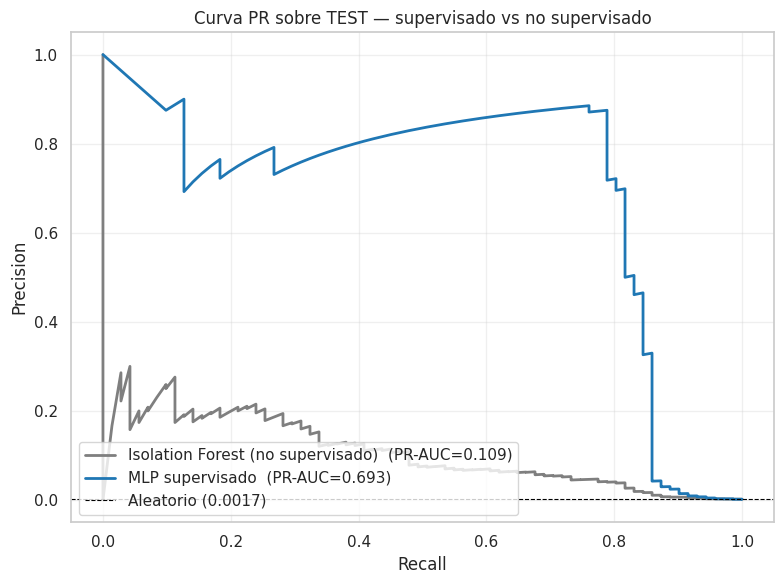

In [ ]:
# fig10 — Curvas PR comparadas sobre test
fig, ax = plt.subplots(figsize=(8, 6))
for score, name, color in [(test_score_if, "Isolation Forest (no supervisado)", "#7f7f7f"),
                            (score_test,    "MLP supervisado",                  "#1f77b4")]:
    p, r, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    ax.plot(r, p, label=f"{name}  (PR-AUC={ap:.3f})", lw=2, color=color)
ax.axhline(y_test.mean(), ls="--", color="black", lw=0.8,
           label=f"Aleatorio ({y_test.mean():.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Curva PR sobre TEST — supervisado vs no supervisado")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout()
savefig("fig10_curva_pr_final_test.png")
plt.show()


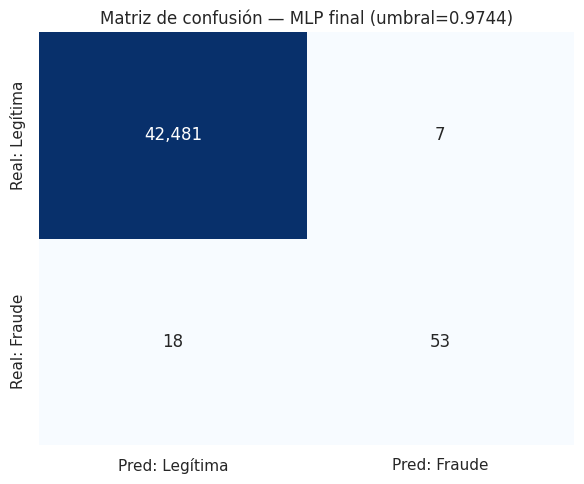

De 71 fraudes reales en test:
  Detectados: 53  (74.6%)
  Perdidos  : 18  (25.4%)
De 42488 legítimas en test:
  Bloqueadas erróneamente: 7  (0.016%)


In [ ]:
# fig11 — Matriz de confusión del modelo elegido sobre test
res_final = finales[1]   # MLP con umbral F2
cm = np.array([[res_final["tn"], res_final["fp"]],
               [res_final["fn"], res_final["tp"]]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Pred: Legítima","Pred: Fraude"],
            yticklabels=["Real: Legítima","Real: Fraude"], ax=ax)
ax.set_title(f"Matriz de confusión — MLP final (umbral={thr_f2:.4f})")
plt.tight_layout()
savefig("fig11_matriz_confusion_final.png")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"De {tp+fn} fraudes reales en test:")
print(f"  Detectados: {tp}  ({tp/(tp+fn)*100:.1f}%)")
print(f"  Perdidos  : {fn}  ({fn/(tp+fn)*100:.1f}%)")
print(f"De {tn+fp} legítimas en test:")
print(f"  Bloqueadas erróneamente: {fp}  ({fp/(tn+fp)*100:.3f}%)")


## 12. Empaquetado de figuras para el informe

In [ ]:
# Comprime el directorio figures/ en un zip descargable
zip_path = "figures_experiencia1.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(FIG_DIR)):
        full = os.path.join(FIG_DIR, fname)
        zf.write(full, arcname=fname)

print(f"Figuras guardadas en {FIG_DIR}/  ({len(os.listdir(FIG_DIR))} PNGs)")
print(f"ZIP listo para descargar: {zip_path}  ({os.path.getsize(zip_path)/1024:.1f} KB)")
print()
print("Archivos en figures/:")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {f}")


Figuras guardadas en figures/  (11 PNGs)
ZIP listo para descargar: figures_experiencia1.zip  (655.9 KB)

Archivos en figures/:
  fig01_desbalance_clases.png
  fig02_distribucion_amount_time.png
  fig03_correlacion_features_class.png
  fig04_distribuciones_top_features.png
  fig05_isolation_forest_baseline.png
  fig06_muestreo_estratificado.png
  fig07_comparacion_estrategias_desbalance.png
  fig08_curvas_aprendizaje_mlp.png
  fig09_curva_pr_validacion_umbrales.png
  fig10_curva_pr_final_test.png
  fig11_matriz_confusion_final.png


In [ ]:
# Reporte final del entorno
import sklearn, imblearn, sys, platform
print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Imbalanced  : {imblearn.__version__}")
print(f"TensorFlow  : {tf.__version__}")
print(f"Semilla     : {SEED}")


Python      : 3.12.3
Platform    : Linux-6.18.5-x86_64-with-glibc2.39
NumPy       : 2.4.4
Pandas      : 3.0.2
Scikit-learn: 1.8.0
Imbalanced  : 0.14.1
TensorFlow  : 2.21.0
Semilla     : 42
